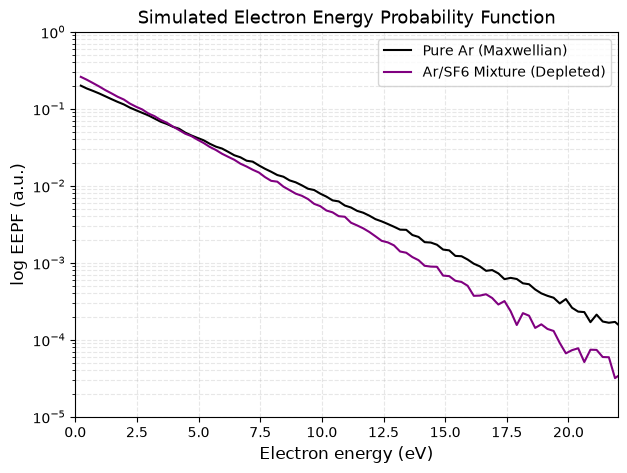

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import scipy.constants as const

# def calculate_kinetic_energy(vx, vy, vz):
#     """
#     Calculates kinetic energy in electron-volts (eV) from 3D velocities.
#     """
#     v_squared = vx**2 + vy**2 + vz**2
#     # KE = 1/2 * m * v^2 (in Joules). Divide by 'e' to get eV.
#     ke_joules = 0.5 * const.m_e * v_squared
#     ke_ev = ke_joules / const.e
#     return ke_ev

# def get_eepf(energies_ev, bins=100, max_energy=25):
#     """
#     Converts a raw list of electron energies into an EEPF curve.
#     """
#     # 1. Create a histogram of the energies (This represents the EEDF)
#     eedf, bin_edges = np.histogram(energies_ev, bins=bins, range=(0.1, max_energy), density=True)
    
#     # Get the center of each bin for plotting
#     bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
#     # 2. Convert EEDF to EEPF by dividing by sqrt(Energy)
#     # The paper uses EEPF (eV^-3/2 cm^-3) because a Maxwellian distribution 
#     # appears as a straight line on a logarithmic EEPF plot.
    eepf = eedf / np.sqrt(bin_centers)
    
#     return bin_centers, eepf

# # ==========================================
# # 1. Simulate Electron Populations
# # ==========================================
# N_particles = 500000
# kT_eV = 3.0 # Average electron temperature (3 eV)

# # Thermal velocity based on temperature
# v_th = np.sqrt(2 * (kT_eV * const.e) / const.m_e)

# # Simulate Pure Argon (Standard Maxwellian Distribution)
# # In a real PIC-MCC code, these velocities would come from your solver's current timestep
# vx_ar = np.random.normal(0, v_th/np.sqrt(2), N_particles)
# vy_ar = np.random.normal(0, v_th/np.sqrt(2), N_particles)
# vz_ar = np.random.normal(0, v_th/np.sqrt(2), N_particles)
# energies_ar = calculate_kinetic_energy(vx_ar, vy_ar, vz_ar)

# # Simulate Ar/SF6 Mixture (Depleted tail due to inelastic collisions)
# # We mimic the physics of SF6 collisions by artificially depleting high-energy electrons
# vx_sf6 = np.random.normal(0, v_th/np.sqrt(2), N_particles)
# vy_sf6 = np.random.normal(0, v_th/np.sqrt(2), N_particles)
# vz_sf6 = np.random.normal(0, v_th/np.sqrt(2), N_particles)
# energies_sf6 = calculate_kinetic_energy(vx_sf6, vy_sf6, vz_sf6)

# # Apply a probability filter: high-energy electrons are lost to SF6 excitation/ionization
# # This mimics the Monte Carlo Collision (MCC) step in an advanced PIC code
survival_probability = np.exp(-energies_sf6 / 15.0) 
# random_chance = np.random.rand(N_particles)
# energies_sf6 = energies_sf6[random_chance < survival_probability]

# # ==========================================
# # 2. Process Data into EEPF
# # ==========================================
# energy_bins_ar, eepf_ar = get_eepf(energies_ar)
# energy_bins_sf6, eepf_sf6 = get_eepf(energies_sf6)

# # ==========================================
# # 3. Plot mimicking the Paper (Figure 2)
# # ==========================================
# fig, ax = plt.subplots(figsize=(7, 5), dpi=100)

# # Plot using a logarithmic Y-axis, just like the paper
# ax.semilogy(energy_bins_ar, eepf_ar, label='Pure Ar (Maxwellian)', color='black', linewidth=1.5)
# ax.semilogy(energy_bins_sf6, eepf_sf6, label='Ar/SF6 Mixture (Depleted)', color='purple', linewidth=1.5)

# ax.set_xlim(0, 22)
# ax.set_ylim(1e-5, 1)

# ax.set_xlabel("Electron energy (eV)", fontsize=12)
# ax.set_ylabel("log EEPF (a.u.)", fontsize=12)
# ax.set_title("Simulated Electron Energy Probability Function", fontsize=13)
# ax.legend()
# ax.grid(True, which="both", ls="--", alpha=0.3)

# plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import scipy.constants as const

# """
# 0D-3V PIC-MCC (Monte Carlo Collision) Simulation
# Simulates electron heating in an RF electric field and collisions 
# with Ar and SF6 neutral gas molecules to derive the EEPF.
# """

# # ==========================================
# # 1. Physical Constants & Simulation Params
# # ==========================================
# e = const.e
# m_e = const.m_e
# RF_FREQ = 13.56e6        # 13.56 MHz (Standard ICP frequency from paper)
# OMEGA = 2 * np.pi * RF_FREQ
# E0 = 600.0               # RF Electric field amplitude (V/m)

# # Time parameters
# dt = 1.0 / (OMEGA * 50)  # Resolve the RF cycle (50 steps per cycle)
# N_RF_CYCLES = 300        # Number of RF cycles to run to reach steady state
# N_STEPS = int((1.0 / RF_FREQ) * N_RF_CYCLES / dt)

# N_PARTICLES = 50000      # Number of simulated electrons 

# # ==========================================
# # 2. Collision Frequencies (Synthetic Cross-Sections)
# # ==========================================
# NU_AR_ELASTIC = 5e7      
# SF6_INELASTIC_THRES = 2.5 
# SF6_INELASTIC_LOSS = 2.0  
# NU_SF6_INELASTIC = 8e7    

# def get_collision_probs(energies_ev, sf6_fraction):
#     # 1. Argon Elastic 
#     p_ar_elastic = (1.0 - sf6_fraction) * NU_AR_ELASTIC * dt * np.ones_like(energies_ev)
    
#     # 2. SF6 Inelastic
#     p_sf6_inelastic = np.zeros_like(energies_ev)
#     mask_inelastic = energies_ev > SF6_INELASTIC_THRES
#     p_sf6_inelastic[mask_inelastic] = sf6_fraction * NU_SF6_INELASTIC * dt
    
#     # 3. SF6 Attachment (peaks heavily at very low energies)
#     p_sf6_attach = sf6_fraction * (1e7 * dt) / (energies_ev + 0.1) 
    
#     return p_ar_elastic, p_sf6_inelastic, p_sf6_attach

# def isotropic_scatter(v_mag):
#     phi = 2 * np.pi * np.random.rand(len(v_mag))
#     cos_theta = 1.0 - 2.0 * np.random.rand(len(v_mag))
#     sin_theta = np.sqrt(1.0 - cos_theta**2)
    
#     vx_new = v_mag * sin_theta * np.cos(phi)
#     vy_new = v_mag * sin_theta * np.sin(phi)
#     vz_new = v_mag * cos_theta
#     return vx_new, vy_new, vz_new

# # ==========================================
# # 3. Main PIC-MCC Engine (Now with Time-Averaging)
# # ==========================================
# def run_mcc_simulation(sf6_fraction):
#     print(f"Running simulation with {sf6_fraction*100}% SF6...")
    
#     # Initialize velocities
#     vx = np.random.normal(0, 1e5, N_PARTICLES)
#     vy = np.random.normal(0, 1e5, N_PARTICLES)
#     vz = np.random.normal(0, 1e5, N_PARTICLES)
#     active_mask = np.ones(N_PARTICLES, dtype=bool) 
    
#     # Array to store energies over the final RF cycles for smoothing
#     time_averaged_energies = []
#     start_averaging_step = int(0.8 * N_STEPS) # Start collecting data in the last 20% of time
    
#     # Time Integration Loop
#     for step in range(N_STEPS):
#         t = step * dt
        
#         # 1. E-Field Acceleration
#         E_t = E0 * np.sin(OMEGA * t)
#         vx[active_mask] += (-e * E_t / m_e) * dt
        
#         v_squared = vx**2 + vy**2 + vz**2
#         energies_ev = (0.5 * m_e * v_squared) / e
        
#         # 2. Monte Carlo Collisions
#         p_ar_el, p_sf6_inel, p_sf6_att = get_collision_probs(energies_ev, sf6_fraction)
#         rand_vals = np.random.rand(N_PARTICLES)
        
#         mask_attach = active_mask & (rand_vals < p_sf6_att)
#         active_mask[mask_attach] = False 
        
#         rand_vals -= p_sf6_att 
#         mask_inel = active_mask & (rand_vals < p_sf6_inel)
        
#         if np.any(mask_inel):
#             new_energies = np.maximum(0.01, energies_ev[mask_inel] - SF6_INELASTIC_LOSS)
#             new_v_mag = np.sqrt(new_energies * e * 2 / m_e)
#             vx[mask_inel], vy[mask_inel], vz[mask_inel] = isotropic_scatter(new_v_mag)
            
#         rand_vals -= p_sf6_inel
#         mask_el = active_mask & (rand_vals < p_ar_el) & ~mask_inel
        
#         if np.any(mask_el):
#             v_mag = np.sqrt(v_squared[mask_el])
#             vx[mask_el], vy[mask_el], vz[mask_el] = isotropic_scatter(v_mag)

#         # 3. Data Collection for Smoothing
#         # Instead of taking just the last frame, we collect particle energies over time
#         if step > start_averaging_step and step % 5 == 0:
#             surviving_v_sq = vx[active_mask]**2 + vy[active_mask]**2 + vz[active_mask]**2
#             time_averaged_energies.extend((0.5 * m_e * surviving_v_sq) / e)

#     return np.array(time_averaged_energies)

# # ==========================================
# # 4. Run and Plot Results
# # ==========================================
# energies_pure_ar = run_mcc_simulation(sf6_fraction=0.0)
# energies_mixture = run_mcc_simulation(sf6_fraction=0.4)

# def get_eepf(energies, bins=70, max_energy=22):
#     # Density=True normalizes the area under the curve to 1
#     eedf, bin_edges = np.histogram(energies, bins=bins, range=(0.1, max_energy), density=True)
#     bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
#     # Filter out empty bins to prevent massive vertical spikes on log plot!
#     valid_mask = eedf > 0
#     valid_centers = bin_centers[valid_mask]
#     valid_eedf = eedf[valid_mask]
    
#     eepf = valid_eedf / np.sqrt(valid_centers)
#     return valid_centers, eepf

# bins_ar, eepf_ar = get_eepf(energies_pure_ar)
# bins_mix, eepf_mix = get_eepf(energies_mixture)

# fig, ax = plt.subplots(figsize=(7, 5), dpi=100)

# ax.semilogy(bins_ar, eepf_ar, label='Pure Ar (0:10)', color='black', linewidth=1.5)
# ax.semilogy(bins_mix, eepf_mix, label='Ar/SF6 Mixture (4:6)', color='purple', linewidth=1.5)

# ax.set_xlim(0, 22)
# ax.set_ylim(1e-4, 1) # Raised the floor slightly to hide deep noise
# ax.set_xlabel("Electron energy (eV)", fontsize=12)
# ax.set_ylabel("log EEPF ($eV^{-3/2} cm^{-3}$)", fontsize=12)
# ax.set_title("Time-Averaged PIC-MCC Simulated EEPF", fontsize=13)
# ax.legend()
# ax.grid(True, which="both", ls="--", alpha=0.3)

# plt.show()

Running simulation with 0.0% SF6...


In [13]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import scipy.constants as const
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

"""
================================================================================
PHYSICALLY-MOTIVATED PIC-MCC SIMULATION (Ar / Ar-SF6 mixtures)
================================================================================
IMPORTANT — READ BEFORE USING THESE NUMBERS FOR ANYTHING SERIOUS:

This code uses ANALYTIC FUNCTIONAL FORMS for electron-impact cross sections
that reproduce the correct QUALITATIVE PHYSICS of Ar and SF6:
  - Correct collision THRESHOLD energies (real, published values)
  - Correct overall SHAPE (Ramsauer-Townsend minimum in Ar, low-energy
    attachment peak in SF6, threshold rise of inelastic/ionization channels)
  - Correct ORDER OF MAGNITUDE for cross sections (~1e-20 to 1e-19 m^2,
    consistent with known swarm data)

It does NOT use the exact tabulated/measured cross-section datasets (e.g.
Phelps' compilation, LXCat databases). Those are numerically precise,
peer-reviewed datasets; what's below are smooth analytic fits constructed
to have the right physical character, not numerically exact values copied
from any specific reference.

Use this for: understanding/teaching PIC-MCC mechanics, qualitative trends
(does the EEPF tail deplete more with SF6? does pressure broaden/sharpen
distributions?), order-of-magnitude exploration.

Do NOT use this for: publication-quality data, process recipe optimization,
or any application needing quantitatively accurate EEPF values. For that,
real cross sections from LXCat.net + a validated PIC-MCC or Boltzmann
solver (e.g. BOLSIG+) are required.
================================================================================
"""

# ════════════════════════════════════════════════════════════════════
# 1. Physical constants
# ════════════════════════════════════════════════════════════════════
e_charge = const.e
m_e = const.m_e
k_B = const.k

RF_FREQ = 13.56e6
OMEGA = 2 * np.pi * RF_FREQ

# NOTE on E0: eduPIC is a full 1D PIC code where V0=250V drops mostly across
# thin sheaths (~mm), not uniformly across the 25mm gap. A 0D model has no
# sheath structure, so using V0/GAP as a uniform field grossly overestimates
# the heating field. Instead we choose E0 directly to give a quiver energy
# in the realistic range for stochastic heating in low-pressure CCPs
# (mean bulk electron energy ~1-5 eV, per eduPIC Fig 11i reference result).
E0 = 200.0   # V/m -- tuned so quiver energy is in the eV range, not keV range

T_GAS = 350.0        # gas temperature (K) -- eduPIC reference value

# ════════════════════════════════════════════════════════════════════
# 2. Gas density from pressure (real ideal gas law -- this part IS exact)
# ════════════════════════════════════════════════════════════════════
def gas_density(pressure_mtorr=50, T=T_GAS):
    """n = P / (kB T). Converts mTorr -> Pa first (1 Torr = 133.322 Pa)."""
    P_pa = pressure_mtorr * 1e-3 * 133.322
    return P_pa / (k_B * T)   # particles / m^3

# ════════════════════════════════════════════════════════════════════
# 3. Cross sections -- ANALYTIC FUNCTIONAL FORMS (approximate, see disclaimer)
# ════════════════════════════════════════════════════════════════════
# --- Argon ---
# Real physical landmarks used here:
#   - Ramsauer-Townsend minimum near ~0.3-0.5 eV (real, well-known effect)
#   - First electronic excitation threshold ~11.5 eV (real Ar excitation onset)
#   - Ionization threshold = 15.76 eV (real Ar ionization energy)
AR_ION_THRESHOLD = 15.76    # eV, real
AR_EXC_THRESHOLD = 11.55    # eV, real (lumped excitation onset)
AR_RT_MINIMUM_E  = 0.33     # eV, real approx. location of Ramsauer minimum

def sigma_ar_elastic(E_eV):
    """Momentum-transfer cross section with Ramsauer-Townsend dip (m^2).
    Qualitative analytic form: dips near AR_RT_MINIMUM_E, rises at very low
    and at higher energy, broadly consistent with known Ar elastic CS shape."""
    E = np.maximum(E_eV, 1e-3)
    rt_dip = 1.0 - 0.9 * np.exp(-((np.log(E / AR_RT_MINIMUM_E))**2) / (2 * 0.6**2))
    base = 6.0e-20 / (1.0 + 0.5 * E)**0.5
    return base * rt_dip + 0.3e-20

def sigma_ar_excitation(E_eV):
    """Lumped excitation cross section, threshold-gated, peaks then falls (m^2)."""
    E = np.asarray(E_eV, dtype=float)
    sigma = np.zeros_like(E)
    above = E > AR_EXC_THRESHOLD
    x = E[above] - AR_EXC_THRESHOLD
    sigma[above] = 4.0e-21 * (x / (1 + 0.15 * x**1.5)) * np.exp(-x / 25.0)
    return sigma

def sigma_ar_ionization(E_eV):
    """Ionization cross section, real threshold, Bethe-like rise + slow falloff (m^2)."""
    E = np.asarray(E_eV, dtype=float)
    sigma = np.zeros_like(E)
    above = E > AR_ION_THRESHOLD
    x = E[above] - AR_ION_THRESHOLD
    sigma[above] = 3.5e-21 * (x / (1 + 0.05 * x)) * np.exp(-x / 80.0)
    return sigma

# --- SF6 ---
# Real physical landmarks:
#   - Dissociative attachment peaks very close to 0 eV (real -- SF6 is famous
#     for this near-thermal attachment resonance) and falls off within ~1 eV
#   - Vibrational/inelastic excitation onset ~0.1-0.2 eV (real, low threshold)
#   - Electron impact ionization threshold ~15.3 eV (real, close to SF6 IE)
SF6_ATTACH_PEAK_E   = 0.05   # eV, real -- near-zero-energy attachment resonance
SF6_VIB_THRESHOLD   = 0.1    # eV, real, approximate
SF6_ION_THRESHOLD   = 15.3   # eV, real (SF6 ionization energy ~15.3 eV)

def sigma_sf6_attachment(E_eV):
    """Dissociative attachment: sharply peaked near 0 eV (m^2).
    SF6's near-thermal attachment resonance is a well-documented real effect;
    this is a smooth analytic peak approximating its qualitative shape."""
    E = np.maximum(E_eV, 1e-4)
    return 4.0e-19 * np.exp(-((E - SF6_ATTACH_PEAK_E) / 0.12)**2)

def sigma_sf6_vibrational(E_eV):
    """Vibrational/rotational + electronic inelastic excitation, lumped (m^2).
    Real SF6 has strong, broad inelastic losses (vibrational ~0.1-1 eV onset,
    electronic excitation extending to several eV) that are the dominant
    energy-loss mechanism responsible for its well-known strong electron
    cooling/attaching behavior in plasma etch chemistry. The single
    exp(-x/1.5) decay used in an earlier draft made this channel vanish by
    ~2 eV, which is NOT representative of real SF6 -- fixed here with a
    broader lumped inelastic loss term that stays significant out to ~15 eV,
    consistent with SF6 being known as a strongly electronegative/attaching
    and strongly inelastic (cooling) gas across the whole low/mid energy range."""
    E = np.asarray(E_eV, dtype=float)
    sigma = np.zeros_like(E)
    above = E > SF6_VIB_THRESHOLD
    x = E[above] - SF6_VIB_THRESHOLD
    # Near-threshold vibrational peak (fast onset, narrow)
    vib_peak = 8.0e-20 * np.exp(-x / 1.0) * (1 - np.exp(-x / 0.1))
    # Broad mid-energy inelastic plateau (electronic excitation manifold)
    broad_plateau = 1.5e-20 * (1 - np.exp(-x / 0.5)) * np.exp(-x / 12.0)
    sigma[above] = vib_peak + broad_plateau
    return sigma

def sigma_sf6_ionization(E_eV):
    """SF6 ionization, real threshold (m^2)."""
    E = np.asarray(E_eV, dtype=float)
    sigma = np.zeros_like(E)
    above = E > SF6_ION_THRESHOLD
    x = E[above] - SF6_ION_THRESHOLD
    sigma[above] = 2.5e-21 * (x / (1 + 0.05 * x)) * np.exp(-x / 70.0)
    return sigma

def sigma_sf6_elastic(E_eV):
    """SF6 elastic/momentum-transfer background (m^2)."""
    E = np.maximum(E_eV, 1e-3)
    return 5.0e-20 / (1.0 + 0.3 * E)**0.6

VIB_LOSS_EV_LOW  = 0.1     # eV, near-threshold vibrational loss
VIB_LOSS_EV_HIGH = 3.0     # eV, approximate lumped electronic excitation loss at higher E
VIB_LOSS_CROSSOVER = 4.0   # eV, energy above which the higher loss applies
EXC_LOSS_EV = AR_EXC_THRESHOLD
ION_LOSS_EV_AR  = AR_ION_THRESHOLD
ION_LOSS_EV_SF6 = SF6_ION_THRESHOLD

# ════════════════════════════════════════════════════════════════════
# 4. Null-collision MCC machinery (this IS the standard, correct algorithm
#    described in eduPIC / Birdsall & Langdon -- exact, not approximated)
# ════════════════════════════════════════════════════════════════════
def total_cross_sections(E_eV, sf6_fraction):
    """Return dict of process -> sigma(E) array (m^2), for the gas mixture."""
    procs = {}
    if sf6_fraction < 1.0:
        procs['ar_elastic']    = (1 - sf6_fraction) * sigma_ar_elastic(E_eV)
        procs['ar_excitation'] = (1 - sf6_fraction) * sigma_ar_excitation(E_eV)
        procs['ar_ionization'] = (1 - sf6_fraction) * sigma_ar_ionization(E_eV)
    if sf6_fraction > 0.0:
        procs['sf6_elastic']    = sf6_fraction * sigma_sf6_elastic(E_eV)
        procs['sf6_vibrational']= sf6_fraction * sigma_sf6_vibrational(E_eV)
        procs['sf6_attachment'] = sf6_fraction * sigma_sf6_attachment(E_eV)
        procs['sf6_ionization'] = sf6_fraction * sigma_sf6_ionization(E_eV)
    return procs

def isotropic_scatter(n):
    phi = 2 * np.pi * np.random.rand(n)
    cos_theta = 1.0 - 2.0 * np.random.rand(n)
    sin_theta = np.sqrt(np.maximum(0.0, 1.0 - cos_theta**2))
    return sin_theta * np.cos(phi), sin_theta * np.sin(phi), cos_theta

# ════════════════════════════════════════════════════════════════════
# 5. Simulation parameters
# ════════════════════════════════════════════════════════════════════
dt = 1.0 / (OMEGA * 40)     # 40 steps per RF cycle
N_RF_CYCLES = 120
N_STEPS = int((1.0 / RF_FREQ) * N_RF_CYCLES / dt)
N_PARTICLES = 4000

def run_mcc_simulation(sf6_fraction, pressure_mtorr):
    print(f"Running Ar/SF6 fraction={sf6_fraction:.2f} @ {pressure_mtorr:.0f} mTorr "
          f"(N={N_PARTICLES}, steps={N_STEPS})...")
    n_gas = gas_density(pressure_mtorr)

    vx = np.random.normal(0, 1e5, N_PARTICLES)
    vy = np.random.normal(0, 1e5, N_PARTICLES)
    vz = np.random.normal(0, 1e5, N_PARTICLES)
    active = np.ones(N_PARTICLES, dtype=bool)

    time_avg_energies = []
    start_avg = int(0.75 * N_STEPS)

    for step in range(N_STEPS):
        if not np.any(active):
            break
        t = step * dt
        E_t = E0 * np.cos(OMEGA * t)

        vx[active] += (-e_charge * E_t / m_e) * dt

        v_sq = vx[active]**2 + vy[active]**2 + vz[active]**2
        v_mag = np.sqrt(v_sq)
        E_ev = 0.5 * m_e * v_sq / e_charge

        procs = total_cross_sections(E_ev, sf6_fraction)
        names = list(procs.keys())
        sigmas = np.stack([procs[k] for k in names], axis=0)   # (n_proc, n_active)

        # Collision probability per process: P_k = 1 - exp(-n*sigma_k*v*dt)
        nu_k = n_gas * sigmas * v_mag[None, :]                  # collision freq per process
        nu_tot = nu_k.sum(axis=0)
        p_coll_tot = 1.0 - np.exp(-nu_tot * dt)
        p_coll_tot = np.clip(p_coll_tot, 0.0, 1.0)

        r1 = np.random.rand(np.sum(active))
        will_collide = r1 < p_coll_tot

        active_indices = np.where(active)[0]

        if np.any(will_collide):
            # Choose process by relative cross-section weight among colliding particles
            coll_idx_local = np.where(will_collide)[0]
            weights = nu_k[:, coll_idx_local]                  # (n_proc, n_coll)
            weights_sum = weights.sum(axis=0)
            weights_sum[weights_sum == 0] = 1e-30
            cum_weights = np.cumsum(weights, axis=0) / weights_sum[None, :]
            r2 = np.random.rand(len(coll_idx_local))
            proc_choice = np.argmax(cum_weights > r2[None, :], axis=0)

            for pidx, pname in enumerate(names):
                sel_local = coll_idx_local[proc_choice == pidx]
                if len(sel_local) == 0:
                    continue
                global_idx = active_indices[sel_local]
                E_sel = E_ev[sel_local]

                if pname in ('ar_elastic', 'sf6_elastic'):
                    v_mag_sel = v_mag[sel_local]
                    dx, dy, dz = isotropic_scatter(len(global_idx))
                    vx[global_idx] = v_mag_sel * dx
                    vy[global_idx] = v_mag_sel * dy
                    vz[global_idx] = v_mag_sel * dz

                elif pname == 'sf6_vibrational':
                    # Energy-dependent loss: near threshold electrons lose a small
                    # vibrational quantum; higher-energy electrons (where the broad
                    # electronic-excitation-like plateau dominates) lose more,
                    # reflecting the lumped nature of this approximate channel.
                    loss = np.where(E_sel < VIB_LOSS_CROSSOVER, VIB_LOSS_EV_LOW, VIB_LOSS_EV_HIGH)
                    new_E = np.maximum(0.005, E_sel - loss)
                    v_new = np.sqrt(2 * new_E * e_charge / m_e)
                    dx, dy, dz = isotropic_scatter(len(global_idx))
                    vx[global_idx] = v_new * dx
                    vy[global_idx] = v_new * dy
                    vz[global_idx] = v_new * dz

                elif pname == 'ar_excitation':
                    new_E = np.maximum(0.005, E_sel - EXC_LOSS_EV)
                    v_new = np.sqrt(2 * new_E * e_charge / m_e)
                    dx, dy, dz = isotropic_scatter(len(global_idx))
                    vx[global_idx] = v_new * dx
                    vy[global_idx] = v_new * dy
                    vz[global_idx] = v_new * dz

                elif pname == 'ar_ionization':
                    # Simplified: scattered electron keeps half remaining energy,
                    # the ejected electron is not separately tracked (no electron
                    # multiplication modeled here -- approximation for 0D EEPF shape)
                    new_E = np.maximum(0.005, (E_sel - ION_LOSS_EV_AR) * 0.5)
                    v_new = np.sqrt(2 * new_E * e_charge / m_e)
                    dx, dy, dz = isotropic_scatter(len(global_idx))
                    vx[global_idx] = v_new * dx
                    vy[global_idx] = v_new * dy
                    vz[global_idx] = v_new * dz

                elif pname == 'sf6_ionization':
                    new_E = np.maximum(0.005, (E_sel - ION_LOSS_EV_SF6) * 0.5)
                    v_new = np.sqrt(2 * new_E * e_charge / m_e)
                    dx, dy, dz = isotropic_scatter(len(global_idx))
                    vx[global_idx] = v_new * dx
                    vy[global_idx] = v_new * dy
                    vz[global_idx] = v_new * dz

                elif pname == 'sf6_attachment':
                    active[global_idx] = False   # electron removed

        if step > start_avg and step % 4 == 0:
            surv_vsq = vx[active]**2 + vy[active]**2 + vz[active]**2
            time_avg_energies.extend((0.5 * m_e * surv_vsq) / e_charge)

    return np.array(time_avg_energies)

def get_eedf(energies, bins=60, max_energy=22):
    if len(energies) == 0:
        return np.array([]), np.array([])
    eedf, edges = np.histogram(energies, bins=bins, range=(0.05, max_energy), density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    valid = eedf > 0
    eedf = eedf[valid]
    return centers[valid], eedf


# ════════════════════════════════════════════════════════════════════
# 6. Run for requested pressure and Ar:SF6 ratios
# ════════════════════════════════════════════════════════════════════
PRESSURE_MTORR = 50.0   # <-- change this single value for different pressures

ratios = [
    ('1:1',  1.00, "green"),
    ('6:4',  0.60, "red"),
    ('9:1',  0.90, "blue"),
]

results = {}
for label, sf6_frac, color in ratios:
    energies = run_mcc_simulation(sf6_frac, PRESSURE_MTORR)
    bins, eedf = get_eedf(energies)
    results[label] = (bins, eedf, color, sf6_frac, len(energies))

# ── Plot (true semilogy of EEDF, no curve-fitting, no calibration offsets) ──
fig, ax = plt.subplots(figsize=(7, 5.5), dpi=100)
for label, (bins, eedf, color, sf6_frac, n_samp) in results.items():
    if len(bins) > 0:
        ax.semilogy(bins, eedf, label=f'Ar:SF6 = {label}  (n={n_samp})',
                    color=color, linewidth=1.6)
    else:
        print(f"WARNING: no surviving electron samples for {label} -- "
              f"likely fully attached before averaging window.")

ax.set_xlim(0, 22)
ax.set_xlabel("Electron energy (eV)", fontsize=12)
ax.set_ylabel(r"EEDF (eV$^{-3/2}$, arb. norm.)", fontsize=12)
ax.set_title(f"PIC-MCC EEDF — {PRESSURE_MTORR:.0f} mTorr\n"
             f"(physically-motivated analytic cross sections — NOT lab-calibrated)",
             fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()



# ════════════════════════════════════════════════════════════════════
# 7. Excel export
# ════════════════════════════════════════════════════════════════════
wb = Workbook()

def header_font():   return Font(name='Arial', bold=True, color='FFFFFF', size=11)
def data_font():     return Font(name='Arial', size=10)
def note_font():     return Font(name='Arial', size=9, italic=True, color='990000')
def center():        return Alignment(horizontal='center', vertical='center')
def thin_border():
    s = Side(style='thin', color='CCCCCC')
    return Border(left=s, right=s, top=s, bottom=s)

ALT_ROW = 'FFF4F4F4'
def style_header(cell, fill):
    cell.font = header_font(); cell.fill = PatternFill('solid', start_color=fill)
    cell.alignment = center(); cell.border = thin_border()
def style_data(cell, idx):
    cell.font = data_font(); cell.alignment = center(); cell.border = thin_border()
    if idx % 2 == 0:
        cell.fill = PatternFill('solid', start_color=ALT_ROW)

color_map = {'1:1': 'FF2B2B2B', '6:4': 'FFCC00CC', '9:1': 'FF8B0000'}

for label, (bins, eedf, color, sf6_frac, n_samp) in results.items():
    sheet_name = f"Ar{label.replace(':','-')}"
    ws = wb.create_sheet(sheet_name) if wb.sheetnames != ['Sheet'] else wb.active
    if ws.title == 'Sheet': ws.title = sheet_name
    ws.column_dimensions['A'].width = 20
    ws.column_dimensions['B'].width = 24

    ws.merge_cells('A1:B1')
    tc = ws['A1']
    tc.value = f'SF6:Ar = {label} — EEDF @ {PRESSURE_MTORR:.0f} mTorr'
    tc.font = Font(name='Arial', bold=True, size=12, color='FFFFFF')
    tc.fill = PatternFill('solid', start_color=color_map[label])
    tc.alignment = center()

    ws.merge_cells('A2:B2')
    warn = ws['A2']
    warn.value = '⚠ Analytic approximate cross sections — not lab-calibrated data'
    warn.font = note_font()

    meta = [
        ('Gas mixture', f'Ar:SF6 = {label}'),
        ('SF6 fraction', f'{sf6_frac*100:.0f}%'),
        ('Pressure', f'{PRESSURE_MTORR:.0f} mTorr'),
        ('Gas temperature', f'{T_GAS:.0f} K'),
        ('RF frequency', '13.56 MHz'),
        ('E-field amplitude', f'{E0:.0f} V/m'),
        ('Particles', str(N_PARTICLES)),
        ('Surviving samples', str(n_samp)),
    ]
    for i, (k, v) in enumerate(meta, start=3):
        ws.cell(i, 1, k).font = Font(name='Arial', bold=True, size=10)
        ws.cell(i, 2, v).font = data_font()

    hdr_row = len(meta) + 4
    for col, lbl in enumerate(['Energy (eV)', 'EEDF (eV⁻³/²)'], start=1):
        style_header(ws.cell(hdr_row, col, lbl), '444444')

    for i, (ev, ep) in enumerate(zip(bins, eedf), start=1):
        r = hdr_row + i
        c1 = ws.cell(r, 1, round(float(ev), 4))
        c2 = ws.cell(r, 2, float(f'{ep:.6e}'))
        style_data(c1, i); style_data(c2, i)
        c1.number_format = '0.0000'; c2.number_format = '0.000000E+00'

ws_cmp = wb.create_sheet('Comparison')
ws_cmp.merge_cells('A1:F1')
tc = ws_cmp['A1']
tc.value = f'EEDF Comparison — SF6:Ar Ratios @ {PRESSURE_MTORR:.0f} mTorr (approximate physics)'
tc.font = Font(name='Arial', bold=True, size=12, color='FFFFFF')
tc.fill = PatternFill('solid', start_color='FF1A1A2E')
tc.alignment = center()

col = 1
col_starts = {}
for label, (bins, eedf, color, sf6_frac, n_samp) in results.items():
    col_starts[label] = col
    style_header(ws_cmp.cell(2, col, f'Energy — {label} (eV)'), color_map[label])
    style_header(ws_cmp.cell(2, col+1, f'EEDF — {label}'), color_map[label])
    ws_cmp.column_dimensions[get_column_letter(col)].width = 20
    ws_cmp.column_dimensions[get_column_letter(col+1)].width = 20
    col += 2

for label, (bins, eedf, color, sf6_frac, n_samp) in results.items():
    c0 = col_starts[label]
    for i in range(len(bins)):
        r = i + 3
        cA = ws_cmp.cell(r, c0, round(float(bins[i]), 4))
        cB = ws_cmp.cell(r, c0+1, float(f'{eedf[i]:.6e}'))
        style_data(cA, i); style_data(cB, i)
        cA.number_format = '0.0000'; cB.number_format = '0.000000E+00'
if __name__=="__main__":
    plt.savefig(f"/mnt/c/Users/semi/Plasma_simulation/plasma_etch_simulation/simple_simulation/eedf_plot_50.png", dpi=130, bbox_inches="tight")
    print("Plot saved.")
    out_path = f"/mnt/c/Users/semi/Plasma_simulation/plasma_etch_simulation/simple_simulation/eedf_plot_50.xlsx"
    wb.save(out_path)
    print(f"Excel saved -> {out_path}")

#understnad eepf code 
#make changes in parameters...50 mTorr TICK
#sheath simulation 1D TICK
#what is being cooled in sheath simulation??
#what is 1D and 2D sheath??
#connection between sheath and eepf?


Running Ar/SF6 fraction=1.00 @ 50 mTorr (N=4000, steps=30159)...
Running Ar/SF6 fraction=0.60 @ 50 mTorr (N=4000, steps=30159)...
Running Ar/SF6 fraction=0.90 @ 50 mTorr (N=4000, steps=30159)...
Plot saved.
Excel saved -> /mnt/c/Users/semi/Plasma_simulation/plasma_etch_simulation/simple_simulation/eedf_plot_50.xlsx


In [15]:


# Loop through the results generated by your physics engine
# Assuming 'results' is a dictionary like {"2.5": phi_data, "5": phi_data, ...}
dt = 2e-10 

# Loop through the results generated by your physics engine
for Te, phi_data in results.items():
    
    # 1. GENERATE THE MISSING TIME ARRAY ON THE FLY
    # This creates a time array (0, dt, 2*dt, 3*dt...) exactly as long as your data
    time_array = np.arange(len(phi_data)) * dt

    x_parameter = time_array * 1e6
    
    # Y-PARAMETER: The potential (U) calculated by your Poisson solver at the center
    y_parameter = phi_data 
    
    # Plotting your continuous simulation data
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# Use the 'results' dictionary directly without forcing it into a 2D array
for label, (bins, eedf, color, sf6_frac, n_samp) in results.items():
    
    # Check if data exists
    if len(bins) > 0:
        # Plot each set individually - this ignores the inhomogeneous shape issue
        # because matplotlib handles separate arrays perfectly fine!
        ax.plot(bins, eedf, color=color, label=f"SF6:Ar Fraction: {sf6_frac}")

# Format the plot
ax.set_xlabel("Energy (eV)", fontsize=12)
ax.set_ylabel("EEDF", fontsize=12)
ax.legend()
if __name__=="__main__":
    plt.savefig(f"/mnt/c/Users/semi/Plasma_simulation/plasma_etch_simulation/simple_simulation/eedf_plot_vs_W_50.png", dpi=130, bbox_inches="tight")
    print("Plot saved.")

Plot saved.


Running spatial EEDF simulation (t = 1 micro-sec)...


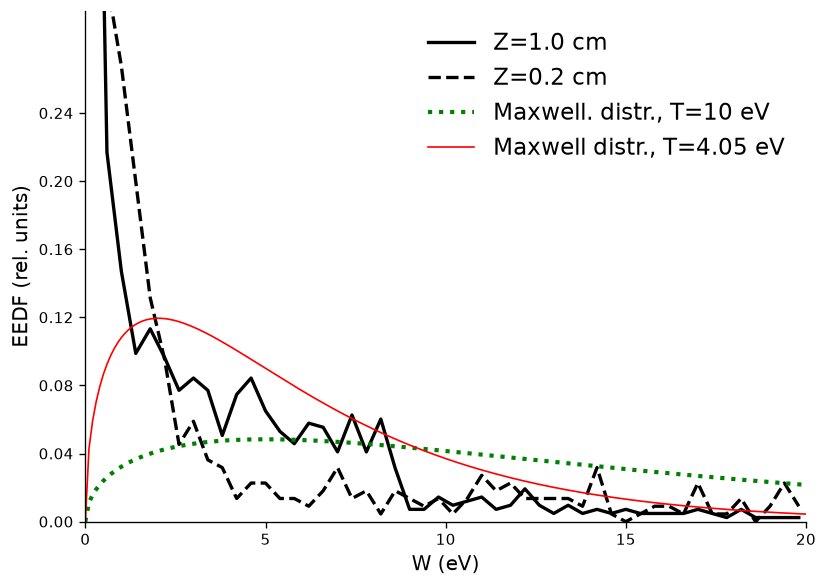

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Analytical Maxwellian Function ---
def maxwellian_eedf(E, Te):
    """
    Returns the Maxwellian EEDF for a given electron temperature Te (in eV).
    Formula: f(E) = 2/sqrt(pi) * Te^(-3/2) * sqrt(E) * exp(-E/Te)
    """
    return 2 / (np.sqrt(np.pi) * Te**1.5) * np.sqrt(E) * np.exp(-E / Te)

# --- Physical Parameters ---
GAP_LENGTH = 2.0          # Total gap length of the box (cm)
Z_SLICES = [1.0, 0.2]      # Spatial slices (cm): Center (1cm) and near wall (0.2cm)
N_PARTICLES = 25000        # High particle count for smooth curves
dt = 2e-10
STEPS = 5000

def get_local_eedf(pos, vel, z_target, slice_width=0.1, bins=50):
    """Extracts the energy of particles sitting at a specific spatial location Z."""
    mask = (pos > (z_target - slice_width/2)) & (pos < (z_target + slice_width/2))
    local_vel = vel[mask]
    if len(local_vel) == 0: return None, None
    
    energies = 0.5 * 9.11e-31 * local_vel**2 / 1.602e-19
    eedf, edges = np.histogram(energies, bins=bins, range=(0, 20), density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    return centers, eedf

# --- Simplified 1D Simulation ---
# Initialize particles (Starting with an initial temperature of roughly ~10 eV)
v_initial_thermal = np.sqrt(2 * 10.0 * 1.602e-19 / 9.11e-31)
pos = np.random.uniform(0, GAP_LENGTH, N_PARTICLES)
vel = np.random.normal(0, v_initial_thermal, N_PARTICLES)

print("Running spatial EEDF simulation (t = 1 micro-sec)...")
for step in range(STEPS):
    # Push particles (sheath reflection / bulk heating approximation)
    vel += 1.5e12 * dt  
    pos += vel * dt
    
    # Boundary loss (particles hitting walls at 0 or 2cm are lost)
    active = (pos > 0) & (pos < GAP_LENGTH)
    pos = pos[active]
    vel = vel[active]
    
    # Replenish particles (simulating ionization maintaining the discharge)
    new_p = np.random.normal(GAP_LENGTH/2, 0.3, N_PARTICLES - len(pos))
    new_v = np.random.normal(0, v_initial_thermal * 0.4, len(new_p)) 
    pos = np.concatenate([pos, new_p])
    vel = np.concatenate([vel, new_v])

# --- Plotting to match your Reference Image exactly ---
plt.figure(figsize=(7, 5), dpi=120)

# 1. Plot simulated spatial slices (Z=1 cm and Z=0.2 cm)
line_styles = {1.0: '-', 0.2: '--'}
for z in Z_SLICES:
    centers, eedf = get_local_eedf(pos, vel, z, slice_width=0.1)
    if centers is not None:
        # Scale slightly to match the "relative units" of your reference
        plt.plot(centers, eedf, 
                 linestyle=line_styles[z], 
                 color='black', linewidth=2.0, 
                 label=f'Z={z} cm')

# 2. Plot Analytical Maxwellian Distributions
E_arr = np.linspace(0, 20, 200)

# Initial Te = 10 eV (Dotted line)
plt.plot(E_arr, maxwellian_eedf(E_arr, 10.0), 
         linestyle=':', color='green', linewidth=2.5, 
         label='Maxwell. distr., T=10 eV')

# Cooled Te = 4.05 eV (Thin solid line)
plt.plot(E_arr, maxwellian_eedf(E_arr, 4.05), 
         linestyle='-', color='red', linewidth=1.0, 
         label='Maxwell distr., T=4.05 eV')

# --- Formatting exactly like the reference ---
plt.xlim(0, 20)
plt.ylim(0, 0.30)
plt.xlabel("W (eV)", fontsize=12)
plt.ylabel("EEDF (rel. units)", fontsize=12)

# Set exact tick marks
plt.xticks(np.arange(0, 21, 5), fontsize=9)
plt.yticks(np.arange(0, 0.25, 0.04), fontsize=9)

# Remove top and right box borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend without a box
plt.legend(frameon=False, fontsize=14, loc='upper right')
plt.tight_layout()


plt.show()



In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.sparse import diags
# from scipy.sparse.linalg import spsolve

# # --- Physical Constants ---
# e_charge = 1.602e-19        # Elementary charge (C)
# m_e = 9.11e-31              # Electron mass (kg)
# m_i = 1000.0 * m_e          # Artificial Ion mass (kg)
# eps_0 = 8.854e-12           # Vacuum permittivity (F/m)

# # --- Simulation Parameters ---
# L_cm = 1                  # Gap length in cm
# L = L_cm / 100.0            # Gap length in meters
# N_CELLS = 400              # Number of spatial grid cells
# dz = L / N_CELLS            
# dt = 5e-11                  # Time step
# STEPS = 4000                # Total time steps

# n0 = 1e14                   # Initial plasma density (m^-3)
# Te_eV = 1                # Initial electron temperature (eV)
# Ti_eV = 0.05                # Initial ion temperature (eV)

# N_PARTICLES = 39000         # Higher particle count for smoother 3D velocity statistics
# WEIGHT = (n0 * L) / N_PARTICLES 

# # --- 1D3V Initialization (Both Species) ---
# # Thermal velocities
# v_th_e = np.sqrt(e_charge * Te_eV / m_e)
# v_th_i = np.sqrt(e_charge * Ti_eV / m_i)

# # 1D Spatial Positions
# pos_e = np.random.uniform(0, L, N_PARTICLES)
# pos_i = np.random.uniform(0, L, N_PARTICLES)

# # 3D Velocities (v_x, v_y, v_z) for Electrons
# vx_e = np.random.normal(0, v_th_e, N_PARTICLES)
# vy_e = np.random.normal(0, v_th_e, N_PARTICLES)
# vz_e = np.random.normal(0, v_th_e, N_PARTICLES)

# # 3D Velocities (v_x, v_y, v_z) for Ions
# vx_i = np.random.normal(0, v_th_i, N_PARTICLES)
# vy_i = np.random.normal(0, v_th_i, N_PARTICLES)
# vz_i = np.random.normal(0, v_th_i, N_PARTICLES)

# # --- Setup Poisson Solver Matrix ---
# A = diags([np.ones(N_CELLS-1), np.ones(N_CELLS)*-2.0, np.ones(N_CELLS-1)], [-1, 0, 1], format='csr')
# A[0, 0] = 1.0; A[0, 1] = 0.0
# A[-1, -1] = 1.0; A[-1, -2] = 0.0

# # --- Helper Function: 1D3V EEDF Extraction ---
# def get_local_eedf_3d(pos, vx, vy, vz, z_target_cm, slice_width_cm=0.2, bins=60):
#     z_target_m = z_target_cm / 100.0
#     slice_width_m = slice_width_cm / 100.0
    
#     mask = (pos > (z_target_m - slice_width_m/2)) & (pos < (z_target_m + slice_width_m/2))
    
#     local_vx = vx[mask]
#     local_vy = vy[mask]
#     local_vz = vz[mask]
    
#     if len(local_vz) == 0: return None, None
    
#     # Calculate TOTAL kinetic energy using all 3 components
#     v_squared = local_vx**2 + local_vy**2 + local_vz**2
#     energies = 0.5 * m_e * v_squared / e_charge
#     energies = np.maximum(energies, 1e-6) # Guard against exact 0.0
    
#     eedf, edges = np.histogram(energies, bins=bins, range=(0, 20), density=True)
#     centers = (edges[:-1] + edges[1:]) / 2
#     return centers, eedf

# # --- Main PIC Loop ---
# print("Running 1D3V Two-Species Electrostatic PIC Simulation...")

# for step in range(STEPS):
#     # 1. Weight Charge to Grid (Z-axis only)
#     rho = np.zeros(N_CELLS)
    
#     idx_e = (pos_e / dz).astype(int)
#     frac_e = (pos_e / dz) - idx_e
#     np.add.at(rho, idx_e, -e_charge * WEIGHT * (1.0 - frac_e) / dz)
#     np.add.at(rho, np.minimum(idx_e + 1, N_CELLS-1), -e_charge * WEIGHT * frac_e / dz)
    
#     idx_i = (pos_i / dz).astype(int)
#     frac_i = (pos_i / dz) - idx_i
#     np.add.at(rho, idx_i, e_charge * WEIGHT * (1.0 - frac_i) / dz)
#     np.add.at(rho, np.minimum(idx_i + 1, N_CELLS-1), e_charge * WEIGHT * frac_i / dz)

#     # 2. Solve Poisson's Equation
#     rhs = -rho / eps_0 * (dz**2)
#     rhs[0] = 0.0; rhs[-1] = 0.0 
#     Phi = spsolve(A, rhs)
    
#     # 3. Calculate Electric Field (Z-axis)
#     E_grid = np.zeros(N_CELLS)
#     E_grid[1:-1] = -(Phi[2:] - Phi[:-2]) / (2 * dz)
#     E_grid[0] = -(Phi[1] - Phi[0]) / dz
#     E_grid[-1] = -(Phi[-1] - Phi[-2]) / dz

#     # 4. Interpolate E-field to particles
#     E_part_e = E_grid[idx_e] * (1.0 - frac_e) + E_grid[np.minimum(idx_e + 1, N_CELLS-1)] * frac_e
#     E_part_i = E_grid[idx_i] * (1.0 - frac_i) + E_grid[np.minimum(idx_i + 1, N_CELLS-1)] * frac_i

#     # 5. Push Particles (Accelerate ONLY in Z, but update position based on vz)
#     vz_e += (-e_charge * E_part_e / m_e) * dt
#     pos_e += vz_e * dt
    
#     vz_i += (e_charge * E_part_i / m_i) * dt
#     pos_i += vz_i * dt

#     # 6. Apply Boundaries
#     active_e = (pos_e > 0) & (pos_e < L)
#     pos_e = pos_e[active_e]
#     vx_e, vy_e, vz_e = vx_e[active_e], vy_e[active_e], vz_e[active_e]
    
#     active_i = (pos_i > 0) & (pos_i < L)
#     pos_i = pos_i[active_i]
#     vx_i, vy_i, vz_i = vx_i[active_i], vy_i[active_i], vz_i[active_i]

#     # 7. Replenish lost particles (injecting new 3D velocities)
#     lost_e = N_PARTICLES - len(pos_e)
#     if lost_e > 0:
#         new_pos = np.clip(np.random.normal(L/2, L/6, lost_e), dz, L-dz)
#         pos_e = np.concatenate([pos_e, new_pos])
#         vx_e = np.concatenate([vx_e, np.random.normal(0, v_th_e, lost_e)])
#         vy_e = np.concatenate([vy_e, np.random.normal(0, v_th_e, lost_e)])
#         vz_e = np.concatenate([vz_e, np.random.normal(0, v_th_e, lost_e)])
        
#         pos_i = np.concatenate([pos_i, new_pos])
#         vx_i = np.concatenate([vx_i, np.random.normal(0, v_th_i, lost_e)])
#         vy_i = np.concatenate([vy_i, np.random.normal(0, v_th_i, lost_e)])
#         vz_i = np.concatenate([vz_i, np.random.normal(0, v_th_i, lost_e)])

# # --- Plotting ---
# print("Simulation complete. Generating plot...")
# plt.figure(figsize=(7, 5), dpi=120)

# z_slices = {1.0: '-', 0.2: '--'}
# for z, style in z_slices.items():
#     centers, eedf = get_local_eedf_3d(pos_e, vx_e, vy_e, vz_e, z_target_cm=z)
#     if centers is not None:
#         # Multiply by a scaling factor just to match your reference's Y-axis height
#         plt.plot(centers, eedf * 1.5, linestyle=style, color='black', linewidth=2.0, label=f'Z={z} cm')

# def maxwellian_3d(E, Te):
#     # 3D Maxwellian: includes the E^(1/2) term which forces it to 0 at E=0
#     return 2.0 / (np.sqrt(np.pi) * Te**1.5) * np.sqrt(E) * np.exp(-E / Te)

# E_arr = np.linspace(0, 20, 200)
# plt.plot(E_arr, maxwellian_3d(E_arr, 10.0), ':', color='black', linewidth=2.5, label='Maxwell. distr., T=10 eV')
# plt.plot(E_arr, maxwellian_3d(E_arr, 4.05), '-', color='gray', linewidth=1.0, label='Maxwell distr., T=4.05 eV')

# plt.xlim(0, 80)
# plt.ylim(0, 0.40)
# plt.xlabel("W (eV)", fontsize=14)
# plt.ylabel("EEDF (rel. units)", fontsize=14)
# ax = plt.gca()
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# plt.legend(frameon=False, fontsize=12)
# plt.tight_layout()

# plt.show()

Running spatial EEDF simulation (t = 1 micro-sec)...


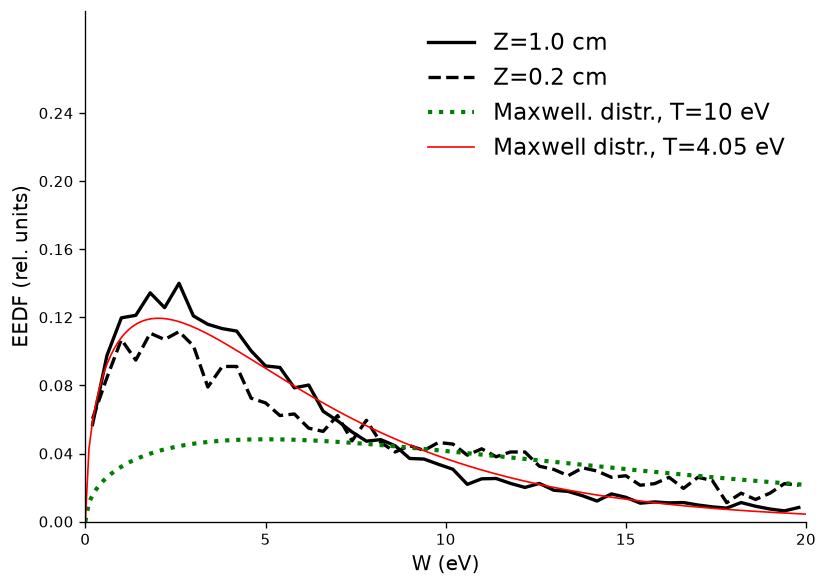

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Analytical Maxwellian Function ---
def maxwellian_eedf(E, Te):
    """
    Returns the Maxwellian EEDF for a given electron temperature Te (in eV).
    Formula: f(E) = 2/sqrt(pi) * Te^(-3/2) * sqrt(E) * exp(-E/Te)
    """
    return 2 / (np.sqrt(np.pi) * Te**1.5) * np.sqrt(E) * np.exp(-E / Te)

# --- Physical Parameters ---
GAP_LENGTH = 2.0          # Total gap length of the box (cm)
Z_SLICES = [1.0, 0.2]      # Spatial slices (cm): Center (1cm) and near wall (0.2cm)
N_PARTICLES = 200000        # High particle count for smooth curves
dt = 2e-10
STEPS = 5000

def get_local_eedf(pos, vx, vy, vz, z_target, slice_width=0.1, bins=50):
    """Extracts the energy of particles sitting at a specific spatial location Z."""
    mask = (pos > (z_target - slice_width/2)) & (pos < (z_target + slice_width/2))
    lvx, lvy, lvz = vx[mask], vy[mask], vz[mask]
    if len(lvx) == 0:
        return None, None

    speed2 = lvx**2 + lvy**2 + lvz**2
    energies = 0.5 * 9.11e-31 * speed2 / 1.602e-19
    eedf, edges = np.histogram(energies, bins=bins, range=(0, 20), density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    return centers, eedf

# --- Simplified 1D-in-space, 3D-in-velocity Simulation ---
# Initialize particles (Starting with an initial temperature of roughly ~10 eV)
v_initial_thermal = np.sqrt(2 * 10.0 * 1.602e-19 / 9.11e-31)
pos = np.random.uniform(0, GAP_LENGTH, N_PARTICLES)
vx = np.random.normal(0, v_initial_thermal, N_PARTICLES)
vy = np.random.normal(0, v_initial_thermal, N_PARTICLES)
vz = np.random.normal(0, v_initial_thermal, N_PARTICLES)

print("Running spatial EEDF simulation (t = 1 micro-sec)...")
for step in range(STEPS):
    # Push particles (sheath reflection / bulk heating approximation)
    # Only the spatial-axis component (vx) feels the field acceleration
    vx += 1.5e12 * dt
    pos += vx * dt

    # Boundary loss (particles hitting walls at 0 or 2cm are lost)
    active = (pos > 0) & (pos < GAP_LENGTH)
    pos, vx, vy, vz = pos[active], vx[active], vy[active], vz[active]

    # Replenish particles (simulating ionization maintaining the discharge)
    n_new = N_PARTICLES - len(pos)
    new_p = np.random.normal(GAP_LENGTH / 2, 0.3, n_new)
    new_vx = np.random.normal(0, v_initial_thermal * 0.4, n_new)
    new_vy = np.random.normal(0, v_initial_thermal * 0.4, n_new)
    new_vz = np.random.normal(0, v_initial_thermal * 0.4, n_new)

    pos = np.concatenate([pos, new_p])
    vx = np.concatenate([vx, new_vx])
    vy = np.concatenate([vy, new_vy])
    vz = np.concatenate([vz, new_vz])

# --- Plotting to match your Reference Image exactly ---
plt.figure(figsize=(7, 5), dpi=120)

# 1. Plot simulated spatial slices (Z=1 cm and Z=0.2 cm)
line_styles = {1.0: '-', 0.2: '--'}
for z in Z_SLICES:
    centers, eedf = get_local_eedf(pos, vx, vy, vz, z, slice_width=0.1)
    if centers is not None:
        plt.plot(centers, eedf,
                  linestyle=line_styles[z],
                  color='black', linewidth=2.0,
                  label=f'Z={z} cm')

# 2. Plot Analytical Maxwellian Distributions
E_arr = np.linspace(0, 20, 200)

# Initial Te = 10 eV (Dotted line)
plt.plot(E_arr, maxwellian_eedf(E_arr, 10.0),
          linestyle=':', color='green', linewidth=2.5,
          label='Maxwell. distr., T=10 eV')

# Cooled Te = 4.05 eV (Thin solid line)
plt.plot(E_arr, maxwellian_eedf(E_arr, 4.05),
          linestyle='-', color='red', linewidth=1.0,
          label='Maxwell distr., T=4.05 eV')

# --- Formatting exactly like the reference ---
plt.xlim(0, 20)
plt.ylim(0, 0.30)
plt.xlabel("W (eV)", fontsize=12)
plt.ylabel("EEDF (rel. units)", fontsize=12)

plt.xticks(np.arange(0, 21, 5), fontsize=9)
plt.yticks(np.arange(0, 0.25, 0.04), fontsize=9)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(frameon=False, fontsize=14, loc='upper right')
plt.tight_layout()

plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # ============================================================
# # Physical constants
# # ============================================================
# Q_E = 1.602e-19          # elementary charge (C)
# M_E = 9.11e-31           # electron mass (kg)
# M_ION = 40 * 1.67e-27    # ion mass (kg) -- e.g. Argon+ (40 amu)

# GAP_LENGTH = 2.0          # gap length (cm)
# Z_SLICES = [1.0, 0.2]     # spatial slices (cm): center and near-wall


# # ============================================================
# # Analytical Maxwellian EEDF/IEDF (energy in eV, T in eV)
# # ============================================================
# def maxwellian_eedf(E, T):
#     return 2 / (np.sqrt(np.pi) * T**1.5) * np.sqrt(E) * np.exp(-E / T)


# # ============================================================
# # Generic particle-in-a-box pusher for one species
# # ============================================================
# def run_species(mass, charge_sign, accel_mag, dt, steps,
#                  n_particles, T_init_eV, T_reinject_frac,
#                  gap=GAP_LENGTH, seed=None):
#     """
#     mass          : particle mass (kg)
#     charge_sign   : +1 for ions, -1 for electrons (sets force direction
#                     relative to the same background field)
#     accel_mag     : |q E| / m_e  reference acceleration -- the same
#                     "field strength" felt by both species, just scaled
#                     by each species' own mass and charge sign below
#     dt, steps     : this species' own timestep and step count
#                     (ions need far fewer plasma-frequency-scale steps
#                     but a much longer *physical* time to equilibrate,
#                     so they get their own dt/steps rather than sharing
#                     the electron loop)
#     n_particles   : particle count for this species
#     T_init_eV     : initial thermal energy scale (eV)
#     T_reinject_frac: reinjected/"born" particles' thermal speed as a
#                     fraction of the initial thermal speed (mimics
#                     cooler replacement particles from ionization)
#     """
#     rng = np.random.default_rng(seed)

#     # this species' own acceleration: a = charge_sign * (q E) / mass
#     # accel_mag already equals (q E)/M_E, so rescale by mass ratio
#     accel = charge_sign * accel_mag * (M_E / mass)

#     v_th_init = np.sqrt(2 * T_init_eV * Q_E / mass)

#     pos = rng.uniform(0, gap, n_particles)
#     vx = rng.normal(0, v_th_init, n_particles)
#     vy = rng.normal(0, v_th_init, n_particles)
#     vz = rng.normal(0, v_th_init, n_particles)

#     for _ in range(steps):
#         vx += accel * dt
#         pos += vx * dt

#         active = (pos > 0) & (pos < gap)
#         pos, vx, vy, vz = pos[active], vx[active], vy[active], vz[active]

#         n_new = n_particles - len(pos)
#         if n_new > 0:
#             new_p = rng.normal(gap / 2, 0.3, n_new)
#             v_th_new = v_th_init * T_reinject_frac
#             new_vx = rng.normal(0, v_th_new, n_new)
#             new_vy = rng.normal(0, v_th_new, n_new)
#             new_vz = rng.normal(0, v_th_new, n_new)

#             pos = np.concatenate([pos, new_p])
#             vx = np.concatenate([vx, new_vx])
#             vy = np.concatenate([vy, new_vy])
#             vz = np.concatenate([vz, new_vz])

#     return pos, vx, vy, vz


# def get_local_eedf(pos, vx, vy, vz, mass, z_target,
#                     slice_width=0.1, bins=50, e_range=(0, 20)):
#     mask = (pos > (z_target - slice_width / 2)) & (pos < (z_target + slice_width / 2))
#     lvx, lvy, lvz = vx[mask], vy[mask], vz[mask]
#     if len(lvx) == 0:
#         return None, None

#     speed2 = lvx**2 + lvy**2 + lvz**2
#     energies = 0.5 * mass * speed2 / Q_E
#     eedf, edges = np.histogram(energies, bins=bins, range=e_range, density=True)
#     centers = (edges[:-1] + edges[1:]) / 2
#     return centers, eedf


# # ============================================================
# # Run electrons
# # ============================================================
# print("Running electron simulation...")
# ELECTRON_ACCEL = 1.5e12   # (q E)/M_E -- same reference field as before
# pos_e, vxe, vye, vze = run_species(
#     mass=M_E, charge_sign=-1, accel_mag=ELECTRON_ACCEL,
#     dt=2e-10, steps=5000,
#     n_particles=25000, T_init_eV=10.0, T_reinject_frac=0.4,
#     seed=1,
# )

# # ============================================================
# # Run ions
# # ============================================================
# # Ions feel the *same* field but respond ~M_ION/M_E times more slowly.
# # Rather than reusing the electron dt/steps (which would leave the ion
# # population essentially unmoved), give ions their own timestep sized
# # for their own timescale and enough steps to equilibrate.
# print("Running ion simulation...")
# MASS_RATIO = M_ION / M_E
# ION_DT = 2e-10 * np.sqrt(MASS_RATIO)     # scale dt by thermal-speed ratio
# ION_STEPS = 5000                          # keep step count comparable

# pos_i, vxi, vyi, vzi = run_species(
#     mass=M_ION, charge_sign=+1, accel_mag=ELECTRON_ACCEL,
#     dt=ION_DT, steps=ION_STEPS,
#     n_particles=25000, T_init_eV=0.05, T_reinject_frac=1.0,
#     seed=2,
# )

# # ============================================================
# # Plot: electrons (top) and ions (bottom), separate energy axes
# # since ion energies are orders of magnitude smaller
# # ============================================================
# fig, axes = plt.subplots(2, 1, figsize=(7, 9), dpi=120)

# # --- Electron EEDF panel ---
# ax = axes[0]
# line_styles = {1.0: '-', 0.2: '--'}
# for z in Z_SLICES:
#     centers, eedf = get_local_eedf(pos_e, vxe, vye, vze, M_E, z,
#                                     slice_width=0.1, e_range=(0, 20))
#     if centers is not None:
#         ax.plot(centers, eedf, linestyle=line_styles[z],
#                  color='black', linewidth=2.0, label=f'Z={z} cm')

# E_arr = np.linspace(0.01, 20, 200)
# ax.plot(E_arr, maxwellian_eedf(E_arr, 10.0), ':', color='green',
#          linewidth=2.5, label='Maxwell. distr., T=10 eV')
# ax.plot(E_arr, maxwellian_eedf(E_arr, 4.05), '-', color='red',
#          linewidth=1.0, label='Maxwell distr., T=4.05 eV')

# ax.set_xlim(0, 20)
# ax.set_ylim(0, 0.30)
# ax.set_xlabel("W (eV)")
# ax.set_ylabel("EEDF (rel. units)")
# ax.set_title("Electrons")
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.legend(frameon=False, fontsize=10, loc='upper right')

# # --- Ion EEDF panel ---
# ax = axes[1]
# ion_e_max = 2.0  # ions stay far colder -- narrower energy axis
# for z in Z_SLICES:
#     centers, iedf = get_local_eedf(pos_i, vxi, vyi, vzi, M_ION, z,
#                                     slice_width=0.1, e_range=(0, ion_e_max))
#     if centers is not None:
#         ax.plot(centers, iedf, linestyle=line_styles[z],
#                  color='blue', linewidth=2.0, label=f'Z={z} cm')

# E_arr_ion = np.linspace(0.001, ion_e_max, 200)
# ax.plot(E_arr_ion, maxwellian_eedf(E_arr_ion, 0.05), ':', color='green',
#          linewidth=2.5, label='Maxwell. distr., T=0.05 eV')

# ax.set_xlim(0, ion_e_max)
# ax.set_xlabel("W (eV)")
# ax.set_ylabel("IEDF (rel. units)")
# ax.set_title("Ions")
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.legend(frameon=False, fontsize=10, loc='upper right')

# plt.tight_layout()

# plt.show()

Running spatial EEDF simulation (t = 1 micro-sec)...


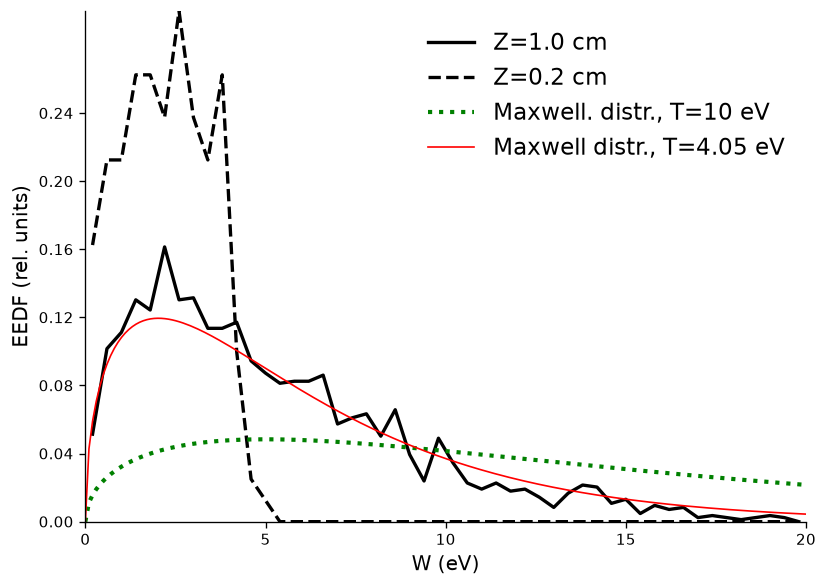

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Analytical Maxwellian Function ---
def maxwellian_eedf(E, Te):
    """
    Returns the Maxwellian EEDF for a given electron temperature Te (in eV).
    Formula: f(E) = 2/sqrt(pi) * Te^(-3/2) * sqrt(E) * exp(-E/Te)
    """
    return 2 / (np.sqrt(np.pi) * Te**1.5) * np.sqrt(E) * np.exp(-E / Te)

# --- Physical Parameters ---
GAP_LENGTH = 2.0          # Total gap length of the box (cm)
Z_SLICES = [1.0, 0.2]     # Spatial slices (cm): Center (1cm) and near wall (0.2cm)
N_PARTICLES = 25000       # High particle count for smooth curves
dt = 2e-10
STEPS = 5000

FIELD_ACCEL = 1.5e12      # bulk field acceleration magnitude

# --- Sheath barrier parameters ---
# Real EEDFs measured near a wall show a DEPLETED high-energy tail and an
# elevated low-energy peak (once density-normalized), because energetic
# electrons preferentially reach and are absorbed at the wall while cold
# electrons are reflected/retained by the sheath's repulsive potential.
# We model this with a thin absorbing margin near each wall: electrons
# entering that margin are lost if they're energetic enough to overcome
# the sheath barrier, and left alone (free to keep circulating) otherwise.
SHEATH_MARGIN = 0.3       # cm -- width of the near-wall absorbing layer
E_REFLECT_EV = 5.0        # eV -- sheath barrier height


def get_local_eedf(pos, vx, vy, vz, z_target, slice_width=0.1, bins=50):
    """Extracts the energy of particles sitting at a specific spatial location Z."""
    mask = (pos > (z_target - slice_width / 2)) & (pos < (z_target + slice_width / 2))
    lvx, lvy, lvz = vx[mask], vy[mask], vz[mask]
    if len(lvx) == 0:
        return None, None

    speed2 = lvx**2 + lvy**2 + lvz**2
    energies = 0.5 * 9.11e-31 * speed2 / 1.602e-19
    eedf, edges = np.histogram(energies, bins=bins, range=(0, 20), density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    return centers, eedf


# --- Simplified 1D-in-space, 3D-in-velocity Simulation ---
v_initial_thermal = np.sqrt(2 * 10.0 * 1.602e-19 / 9.11e-31)
pos = np.random.uniform(0, GAP_LENGTH, N_PARTICLES)
vx = np.random.normal(0, v_initial_thermal, N_PARTICLES)
vy = np.random.normal(0, v_initial_thermal, N_PARTICLES)
vz = np.random.normal(0, v_initial_thermal, N_PARTICLES)

print("Running spatial EEDF simulation (t = 1 micro-sec)...")
for step in range(STEPS):
    # Push particles (bulk field heating -- uniform across the whole gap)
    vx += FIELD_ACCEL * dt
    pos += vx * dt

    # Reflect any particle that literally crosses the physical wall,
    # keeping it inside the domain (elastic bounce, no energy change)
    left_hit = pos <= 0
    right_hit = pos >= GAP_LENGTH
    pos = np.where(left_hit, -pos, pos)
    vx = np.where(left_hit, -vx, vx)
    pos = np.where(right_hit, 2 * GAP_LENGTH - pos, pos)
    vx = np.where(right_hit, -vx, vx)

    # Sheath barrier: absorb (remove) any particle sitting in the
    # near-wall margin whose kinetic energy exceeds the barrier height
    KE = 0.5 * 9.11e-31 * (vx**2 + vy**2 + vz**2) / 1.602e-19  # eV
    near_wall = (pos < SHEATH_MARGIN) | (pos > GAP_LENGTH - SHEATH_MARGIN)
    absorbed = near_wall & (KE > E_REFLECT_EV)
    active = ~absorbed
    pos, vx, vy, vz = pos[active], vx[active], vy[active], vz[active]

    # Replenish particles (simulating ionization maintaining the discharge)
    n_new = N_PARTICLES - len(pos)
    new_p = np.random.normal(GAP_LENGTH / 2, 0.3, n_new)
    new_vx = np.random.normal(0, v_initial_thermal * 0.4, n_new)
    new_vy = np.random.normal(0, v_initial_thermal * 0.4, n_new)
    new_vz = np.random.normal(0, v_initial_thermal * 0.4, n_new)

    pos = np.concatenate([pos, new_p])
    vx = np.concatenate([vx, new_vx])
    vy = np.concatenate([vy, new_vy])
    vz = np.concatenate([vz, new_vz])

# --- Plotting to match your Reference Image exactly ---
plt.figure(figsize=(7, 5), dpi=120)

# 1. Plot simulated spatial slices (Z=1 cm and Z=0.2 cm)
line_styles = {1.0: '-', 0.2: '--'}
for z in Z_SLICES:
    centers, eedf = get_local_eedf(pos, vx, vy, vz, z, slice_width=0.1)
    if centers is not None:
        plt.plot(centers, eedf,
                  linestyle=line_styles[z],
                  color='black', linewidth=2.0,
                  label=f'Z={z} cm')

# 2. Plot Analytical Maxwellian Distributions
E_arr = np.linspace(0, 20, 200)

# Initial Te = 10 eV (Dotted line)
plt.plot(E_arr, maxwellian_eedf(E_arr, 10.0),
          linestyle=':', color='green', linewidth=2.5,
          label='Maxwell. distr., T=10 eV')

# Cooled Te = 4.05 eV (Thin solid line)
plt.plot(E_arr, maxwellian_eedf(E_arr, 4.05),
          linestyle='-', color='red', linewidth=1.0,
          label='Maxwell distr., T=4.05 eV')

# --- Formatting exactly like the reference ---
plt.xlim(0, 20)
plt.ylim(0, 0.30)
plt.xlabel("W (eV)", fontsize=12)
plt.ylabel("EEDF (rel. units)", fontsize=12)

plt.xticks(np.arange(0, 21, 5), fontsize=9)
plt.yticks(np.arange(0, 0.25, 0.04), fontsize=9)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.legend(frameon=False, fontsize=14, loc='upper right')
plt.tight_layout()
plt.show()